In [9]:
import pandas as pd
import numpy as np



In [10]:
df=pd.read_csv('ProcessedData1.csv')

In [11]:
df.head()



,,enrollment,duration,phase_encoded,condition_encoded,sponsor_type_INDUSTRY,sponsor_type_NIH,sponsor_type_OTHER,gender_MALE,final_status_success,location_United States
0,0,0.0,0.0,1,5,0,1,0,0,1,0
1,2,0.0,0.0,1,5,0,0,0,0,0,1
2,3,-8223.0,3755.0,1,7,0,1,0,1,1,1
3,4,0.0,0.0,1,1,0,1,0,0,0,1
4,5,0.0,0.0,1,2,0,1,0,0,0,1


In [14]:
df.columns

Index(['      ', ' enrollment', ' duration', ' phase_encoded',
       ' condition_encoded', ' sponsor_type_INDUSTRY', ' sponsor_type_NIH',
       ' sponsor_type_OTHER', ' gender_MALE', ' final_status_success',
       ' location_United States'],
      dtype='object')

In [15]:
df = df.drop(df.columns[0], axis=1)



In [16]:
df.head()

,enrollment,duration,phase_encoded,condition_encoded,sponsor_type_INDUSTRY,sponsor_type_NIH,sponsor_type_OTHER,gender_MALE,final_status_success,location_United States
0,0.0,0.0,1,5,0,1,0,0,1,0
1,0.0,0.0,1,5,0,0,0,0,0,1
2,-8223.0,3755.0,1,7,0,1,0,1,1,1
3,0.0,0.0,1,1,0,1,0,0,0,1
4,0.0,0.0,1,2,0,1,0,0,0,1


In [18]:
from sklearn.model_selection import train_test_split

# Assuming 'final status success' is the target column
target = ' final_status_success'
features = df.drop(target, axis=1)

# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(features, df[target], test_size=0.2, random_state=42)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

Training features shape: (94985, 9)
Testing features shape: (23747, 9)


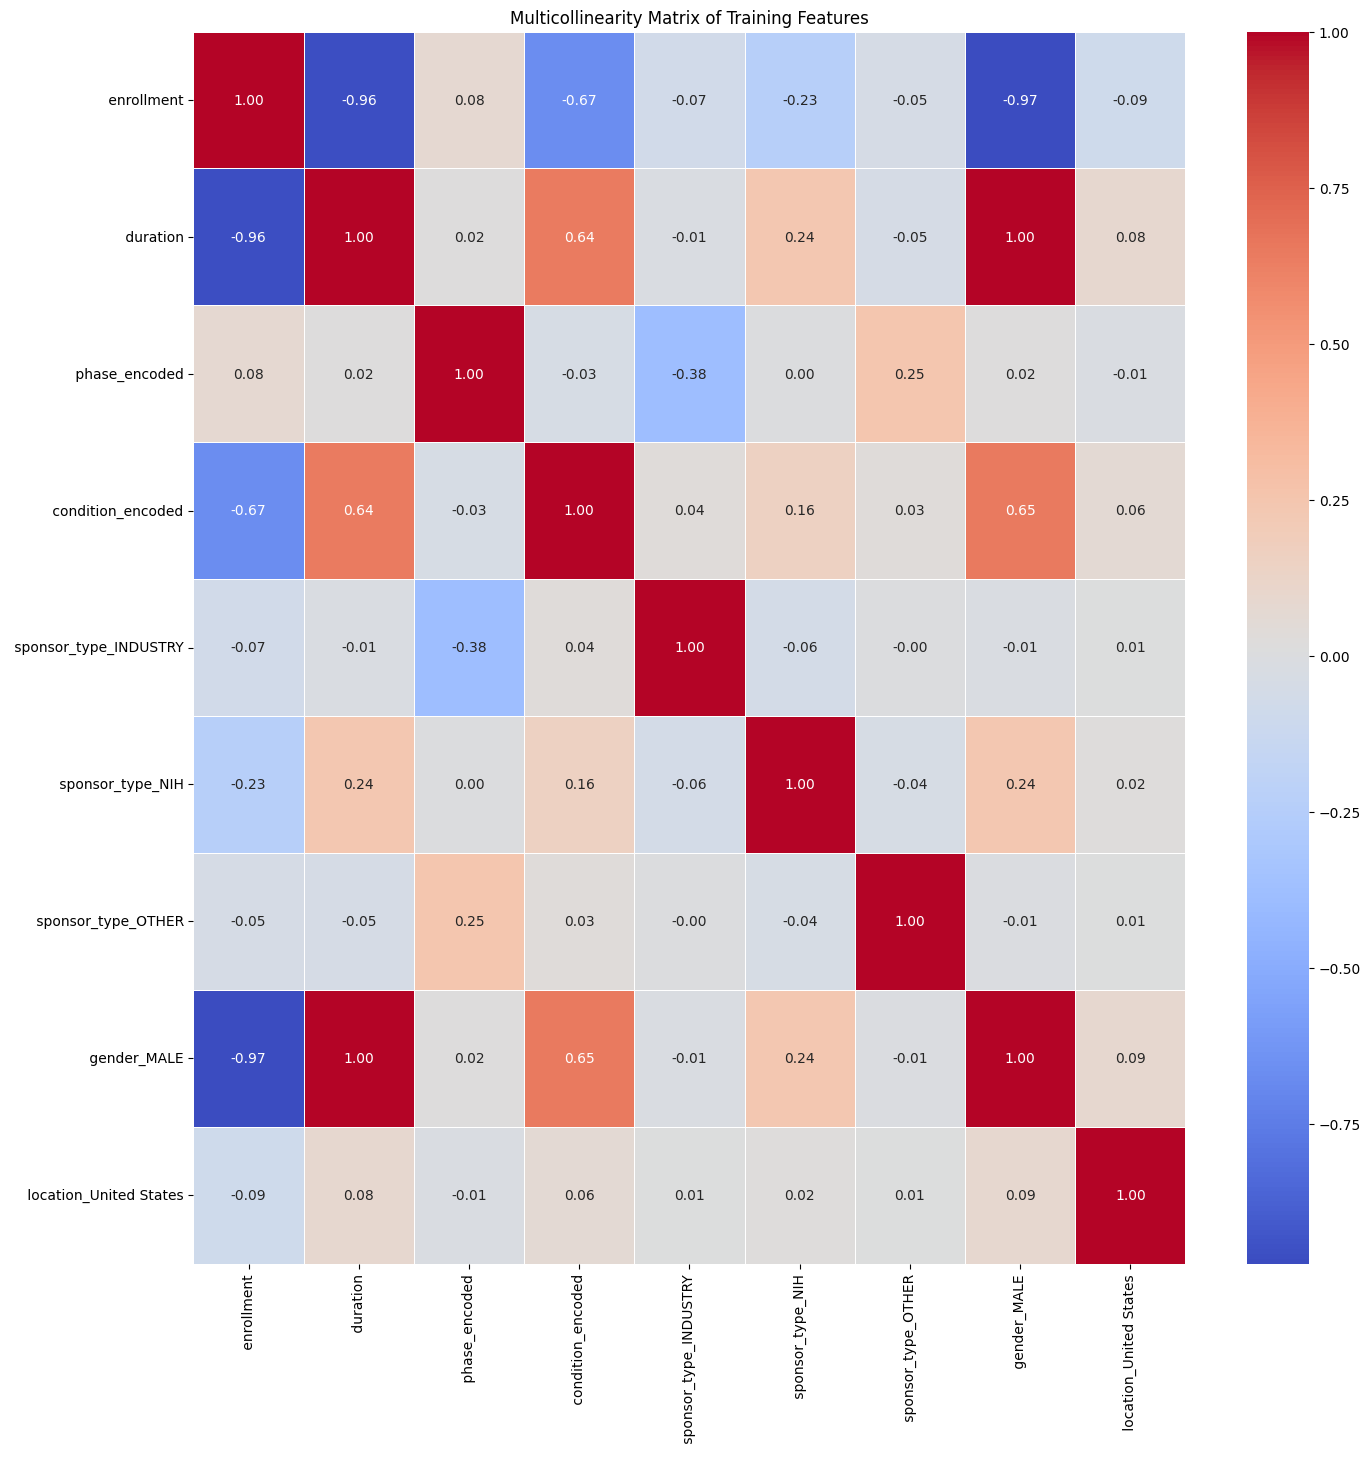

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
corr_matrix = X_train.corr()

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(16, 16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Multicollinearity Matrix of Training Features')
plt.show()


In [20]:
# Find features with high correlation
# Create a set to hold the names of features to drop
features_to_drop = set()

# Iterate through the correlation matrix
# Start from the second column to avoid comparing a feature with itself and
# to avoid adding the same pair of correlated features twice (e.g., A vs B and B vs A)
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        # Check if the absolute correlation between the two features is high
        if abs(corr_matrix.iloc[i, j]) > 0.7:  # You can adjust this threshold
            # Get the names of the two features
            colname_i = corr_matrix.columns[i]
            colname_j = corr_matrix.columns[j]
            # Add the second feature to the set of features to drop.
            # This is a heuristic; you might want a more sophisticated method
            # to decide which feature to keep (e.g., based on importance).
            features_to_drop.add(colname_i)

print("Features to drop due to high multicollinearity:", features_to_drop)



Features to drop due to high multicollinearity: {' gender_MALE', ' duration'}


In [21]:
# Drop the identified features from the training and testing sets
X_train_reduced = X_train.drop(columns=features_to_drop)
X_test_reduced = X_test.drop(columns=features_to_drop)

print("Reduced Training features shape:", X_train_reduced.shape)
print("Reduced Testing features shape:", X_test_reduced.shape)

Reduced Training features shape: (94985, 7)
Reduced Testing features shape: (23747, 7)


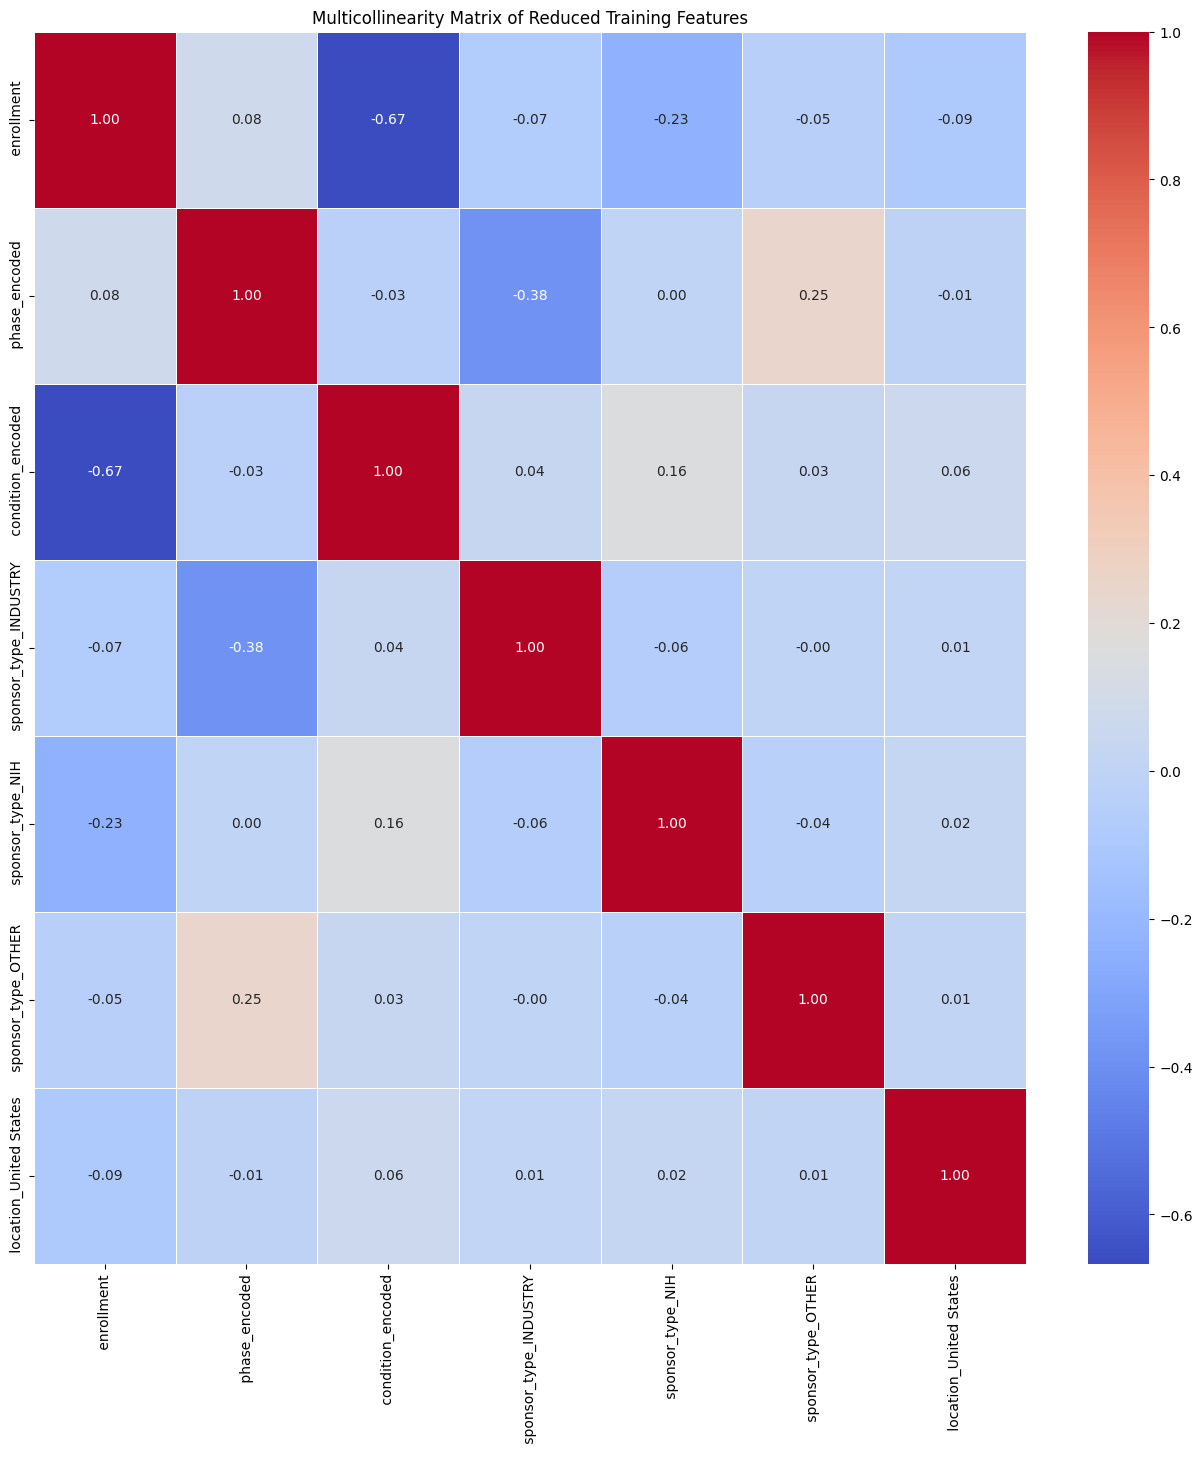

In [22]:

corr_matrix_reduced = X_train_reduced.corr()

# Create a heatmap for the reduced set
plt.figure(figsize=(16, 16)) # Adjust size as needed
sns.heatmap(corr_matrix_reduced, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Multicollinearity Matrix of Reduced Training Features')
plt.show()




In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
# STEP 1: Prepare your data
target = ' final_status_success'
features = df.drop(target, axis=1)
X = features
y = df[target]
# Optional: One-hot encode if there are categorical features
# X = pd.get_dummies(X, drop_first=True)
# STEP 2: Train-test split
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# STEP 3: Define base model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
# STEP 4: Define parameter grid
param_grid = {
   'n_estimators': [50, 100],
   'max_depth': [3, 5],
   'learning_rate': [0.05, 0.1],
   'subsample': [0.8, 1],
   'colsample_bytree': [0.8, 1]
}
# STEP 5: Grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid,
                          scoring='recall',  # You can also use 'accuracy', 'f1', etc.
                          cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train_reduced, y_train)
# STEP 6: Get the best model
best_model = grid_search.best_estimator_
# STEP 7: Predict on test set
y_pred = best_model.predict(X_test_reduced)
# STEP 8: Evaluation
print("Best Parameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 32 candidates, totalling 160 fits


/usr/local/python/3.12.1/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [10:01:09] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/python/3.12.1/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [10:01:09] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/python/3.12.1/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [10:01:09] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/python/3.12.1/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [10:01:09] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/python/3.12.1/lib/python3.12/site

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Accuracy: 0.7031625047374405
Recall: 0.4025258518392948

Classification Report:
               precision    recall  f1-score   support

           0       0.63      1.00      0.77     11949
           1       1.00      0.40      0.57     11798

    accuracy                           0.70     23747
   macro avg       0.81      0.70      0.67     23747
weighted avg       0.81      0.70      0.67     23747

Confusion Matrix:
 [[11949     0]
 [ 7049  4749]]


In [29]:
import joblib
# Save model to a .pkl file
joblib.dump(best_model, 'xgb_model.pkl')

['xgb_model.pkl']

In [30]:
import tarfile
# Create a tar file and add the model file
with tarfile.open('xgb_model.tar', 'w') as tar:
   tar.add('xgb_model.pkl')